# Setup

In [1]:
%pip install xxhash pandas matplotlib numpy

117.38s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 1.5 MB/s  0:00:07a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 1.6 MB/s  0:00:05a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.6 MB/s  0:00:10m 1.6 MB/s eta 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.7 MB/s  0:00:03m 1.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.8 MB/s  0:00:002.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 1.5 MB/s  0:00:04 eta 0:00:010:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (

In [12]:
import uuid
from random import randint, sample, shuffle
from typing import Dict, List, Optional
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from anchorhash import AnchorHasher

In [13]:
class Hascher(ABC):
    @abstractmethod
    def getShard(self, record_id: str) -> int:
        pass

    @abstractmethod
    def addShard(self, shard_id: int):
        pass

    @abstractmethod
    def dropShard(self, shard_id: int):
        pass

In [14]:
class AnchorHasherAdapter(Hascher):
    def __init__(
        self, working_set: List[str], capacity: int, seed: Optional[int] = None
    ) -> None:
        self._impl = AnchorHasher(working_set, capacity=capacity, seed=seed)
        self.name = self._impl.name

    def getShard(self, record_id: str) -> int:
        return self._impl.getShard(record_id)

    def addShard(self, shard_id: int) -> None:
        self._impl.addShard(shard_id)

    def dropShard(self, shard_id: int) -> None:
        self._impl.dropShard(shard_id)

In [15]:
def generate_removal_different_places(original_order, distance):
    n = len(original_order)
    scramble_count = int(n * distance)
    map = {}

    for i in range(n):
        if i+scramble_count > n:
            break

        # Split the array into three parts
        before = original_order[:i]
        middle = original_order[i:i+scramble_count]
        after = original_order[i+scramble_count:]

        # Shuffle the middle part
        shuffle(middle)

        # Combine the parts back together
        new_order = before + middle + after

        # Save the new order in the map with the starting index as key
        map[i] = new_order
    
    return map 

def generate_records(count: int = 100000) -> List[uuid.UUID]:
    """Generate a list of random records for testing."""
    return [uuid.uuid1() for i in range(count)]

def run_single_distance_experiment(
    h_default: Hascher, h_variant: Hascher, records: List, distance: float
) -> float:
    """Run experiment for single distance value and return failure rate."""
    mismatches = 0
    for r in records:
        if h_default.getShard(str(r)) != h_variant.getShard(str(r)):
            mismatches += 1
    failure_rate = mismatches / len(records)
    print(f"distance={distance:.2f} mismatches={mismatches} rate={failure_rate:.4f}")
    return failure_rate

# Experiment

distance=0.00 mismatches=33033 rate=0.3303
distance=1.00 mismatches=33207 rate=0.3321
distance=2.00 mismatches=33140 rate=0.3314
distance=3.00 mismatches=33361 rate=0.3336
distance=4.00 mismatches=33073 rate=0.3307
distance=5.00 mismatches=33151 rate=0.3315
distance=6.00 mismatches=32950 rate=0.3295
distance=7.00 mismatches=32876 rate=0.3288
distance=8.00 mismatches=33237 rate=0.3324
distance=9.00 mismatches=33091 rate=0.3309
distance=10.00 mismatches=33309 rate=0.3331
distance=11.00 mismatches=33141 rate=0.3314
distance=12.00 mismatches=32771 rate=0.3277
distance=13.00 mismatches=33192 rate=0.3319
distance=14.00 mismatches=33151 rate=0.3315
distance=15.00 mismatches=33032 rate=0.3303
distance=16.00 mismatches=33304 rate=0.3330
distance=17.00 mismatches=33083 rate=0.3308
distance=18.00 mismatches=33016 rate=0.3302
distance=19.00 mismatches=32798 rate=0.3280
distance=20.00 mismatches=33144 rate=0.3314
distance=21.00 mismatches=33254 rate=0.3325
distance=22.00 mismatches=33197 rate=0.332

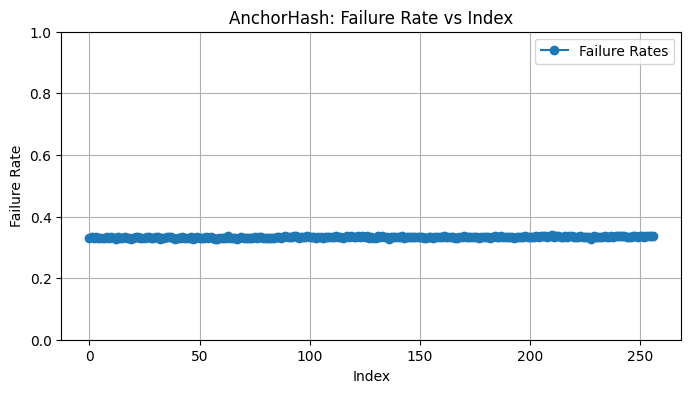

In [16]:
RECORDS = generate_records(100000)

total_shards = 1024
drop_shards_cnt = int(total_shards * 0.50)
dropped_shards = sample(range(total_shards), drop_shards_cnt)

map = generate_removal_different_places(dropped_shards, 0.5)

indexes = sorted(map.keys())
results = {}

# Run experiments for each distance
for d in indexes:
    diff_order = map[d]
    seed = randint(0, 2**32 - 1)

    # Create hasher instances
    h_default = AnchorHasherAdapter(
        [str(i) for i in range(total_shards)], capacity=total_shards, seed=seed
    )
    h_variant = AnchorHasherAdapter(
        [str(i) for i in range(total_shards)], capacity=total_shards, seed=seed
    )
    # Apply removals
    for s in reversed(dropped_shards):
        h_default.dropShard(s)
    for s in reversed(diff_order):
        h_variant.dropShard(s)

    # Calculate and store failure rate
    failure_rate = run_single_distance_experiment(
        h_default, h_variant, RECORDS, d
    )
    
    results[d] = {
        "index": d,
        "failure_rates": failure_rate,
        "dropped_shards": dropped_shards,
    }

# Plot the results
plt.figure(figsize=(8, 4))

# Extract data for plotting
distances = [result["index"] for result in results.values()]
failure_rates = [result["failure_rates"] for result in results.values()]

# Plot the data
plt.plot(distances, failure_rates, marker='o', label='Failure Rates')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Failure Rate")
plt.title("AnchorHash: Failure Rate vs Index")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Show the plot
plt.show()